In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("C:\\Thiranex Internship Tasks\\Retail Sales Analysis\\Data\\retail_sales_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (120000, 17)

Column Names:
['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region']

First 5 Rows:


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,120000,120000,T0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,120000,730,2024-03-30,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,120000,24784,C014343,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_gender,120000,3,Female,40268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age_group,120000,5,35-44,24196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,120000,4,VIP,30115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,120000,120,P1016,1096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,120000,40,Dumbbells,3108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,120000,8,Sports,15218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,120000,3,Brand 1,40240,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64


In [8]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print(df["transaction_date"].dtype)

datetime64[ns]


In [11]:
print("Minimum Transaction Date:", df["transaction_date"].min())
print("Maximum Transaction Date:", df["transaction_date"].max())

Minimum Transaction Date: 2024-01-01 00:00:00
Maximum Transaction Date: 2025-12-30 00:00:00


In [12]:
print("Unique Transactions:", df["transaction_id"].nunique())
print("Unique Customers:", df["customer_id"].nunique())
print("Unique Products:", df["product_id"].nunique())
print("Unique Categories:", df["category"].nunique())
print("Unique Brands:", df["brand"].nunique())

Unique Transactions: 120000
Unique Customers: 24784
Unique Products: 120
Unique Categories: 8
Unique Brands: 3


In [13]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount_pct",
    "sales_amount"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,120000.0,1.662908,1.014291,1.00,1.00,1.00,2.0,5.00
unit_price,120000.0,240.621785,146.457057,7.73,102.01,238.75,379.0,493.51
discount_pct,120000.0,5.496500,8.193257,0.00,0.00,0.00,10.0,30.00
sales_amount,120000.0,377.975454,356.893357,5.41,136.86,295.98,461.5,2467.55


In [14]:
print("Quantity <= 0:", (df["quantity"] <= 0).sum())
print("Unit Price <= 0:", (df["unit_price"] <= 0).sum())
print("Discount < 0:", (df["discount_pct"] < 0).sum())
print("Discount > 100:", (df["discount_pct"] > 100).sum())
print("Sales Amount <= 0:", (df["sales_amount"] <= 0).sum())

Quantity <= 0: 0
Unit Price <= 0: 0
Discount < 0: 0
Discount > 100: 0
Sales Amount <= 0: 0


In [15]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate transaction IDs:", df["transaction_id"].duplicated().sum())

Duplicate rows: 0
Duplicate transaction IDs: 0


In [16]:
categorical_columns = [
    "customer_gender",
    "customer_age_group",
    "customer_segment",
    "category",
    "brand",
    "payment_method",
    "sales_channel",
    "region"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


customer_gender:
customer_gender
Female    40268
Other     39906
Male      39826
Name: count, dtype: int64

customer_age_group:
customer_age_group
35-44    24196
55+      24078
18-24    23941
45-54    23919
25-34    23866
Name: count, dtype: int64

customer_segment:
customer_segment
VIP          30115
New          30020
Loyal        30014
Returning    29851
Name: count, dtype: int64

category:
category
Sports         15218
Clothing       15156
Beauty         15073
Groceries      15034
Toys           15022
Electronics    15008
Home           14933
Books          14556
Name: count, dtype: int64

brand:
brand
Brand 1    40240
Brand 2    39918
Brand 3    39842
Name: count, dtype: int64

payment_method:
payment_method
Credit Card    24262
Cash           24034
PayPal         23998
Debit Card     23897
Gift Card      23809
Name: count, dtype: int64

sales_channel:
sales_channel
Mobile App    40204
In-Store      40049
Online        39747
Name: count, dtype: int64

region:
region
Central    24

In [17]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (120000, 17)

Missing values:
0

Duplicate rows:
0

Data types:
transaction_id                object
transaction_date      datetime64[ns]
customer_id                   object
customer_gender               object
customer_age_group            object
customer_segment              object
product_id                    object
product_name                  object
category                      object
brand                         object
quantity                       int64
unit_price                   float64
discount_pct                   int64
sales_amount                 float64
payment_method                object
sales_channel                 object
region                        object
dtype: object


In [19]:
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["month_name"] = df["transaction_date"].dt.month_name()
df["day"] = df["transaction_date"].dt.day
df["day_of_week"] = df["transaction_date"].dt.day_name()
df["quarter"] = df["transaction_date"].dt.quarter

In [20]:
df["gross_amount"] = df["quantity"] * df["unit_price"]

In [21]:
df["discount_amount"] = df["gross_amount"] * (df["discount_pct"] / 100)

In [22]:
df[[
    "quantity",
    "unit_price",
    "discount_pct",
    "gross_amount",
    "discount_amount",
    "sales_amount"
]].head(10)

,quantity,unit_price,discount_pct,gross_amount,discount_amount,sales_amount
0,2,313.53,20,627.06,125.412,501.65
1,1,366.16,0,366.16,0.000,366.16
2,1,27.99,0,27.99,0.000,27.99
3,2,102.01,15,204.02,30.603,173.42
4,1,259.55,0,259.55,0.000,259.55
5,1,474.70,0,474.70,0.000,474.70
6,1,53.35,0,53.35,0.000,53.35
7,4,17.58,0,70.32,0.000,70.32
8,1,307.87,10,307.87,30.787,277.08
9,1,41.90,25,41.90,10.475,31.42


In [23]:
print("New Shape:", df.shape)

display(df.head())

print("\nNew Columns:")
print(df.columns.tolist())

New Shape: (120000, 25)


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,year,month,month_name,day,day_of_week,quarter,gross_amount,discount_amount
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,2024,4,April,24,Wednesday,2,627.06,125.412
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,2025,7,July,12,Saturday,3,366.16,0.000
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,2025,6,June,1,Sunday,2,27.99,0.000
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,2025,8,August,26,Tuesday,3,204.02,30.603
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,2024,12,December,10,Tuesday,4,259.55,0.000



New Columns:
['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'payment_method', 'sales_channel', 'region', 'year', 'month', 'month_name', 'day', 'day_of_week', 'quarter', 'gross_amount', 'discount_amount']


In [24]:
print("Years:", sorted(df["year"].unique()))
print("\nMonths:", df["month"].unique())
print("\nQuarters:", sorted(df["quarter"].unique()))
print("\nDays of Week:")
print(df["day_of_week"].value_counts())

Years: [2024, 2025]

Months: [ 4  7  6  8 12  2 10  1  9 11  3  5]

Quarters: [1, 2, 3, 4]

Days of Week:
day_of_week
Sunday       17289
Saturday     17270
Wednesday    17231
Monday       17190
Tuesday      17067
Thursday     17028
Friday       16925
Name: count, dtype: int64


In [25]:
total_sales = df["sales_amount"].sum()
total_gross = df["gross_amount"].sum()
total_discount = df["discount_amount"].sum()
total_quantity = df["quantity"].sum()

print("===== RETAIL SALES SUMMARY =====")
print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Gross Amount: ₹{total_gross:,.2f}")
print(f"Total Discount Given: ₹{total_discount:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Transaction Value: ₹{df['sales_amount'].mean():,.2f}")
print(f"Average Quantity per Transaction: {df['quantity'].mean():.2f}")

===== RETAIL SALES SUMMARY =====
Total Sales: ₹45,357,054.45
Total Gross Amount: ₹47,996,218.00
Total Discount Given: ₹2,639,158.34
Total Quantity Sold: 199,549
Average Transaction Value: ₹377.98
Average Quantity per Transaction: 1.66


In [32]:
import os

os.makedirs("../visualizations", exist_ok=True)

print("Visualizations folder ready!")

Visualizations folder ready!


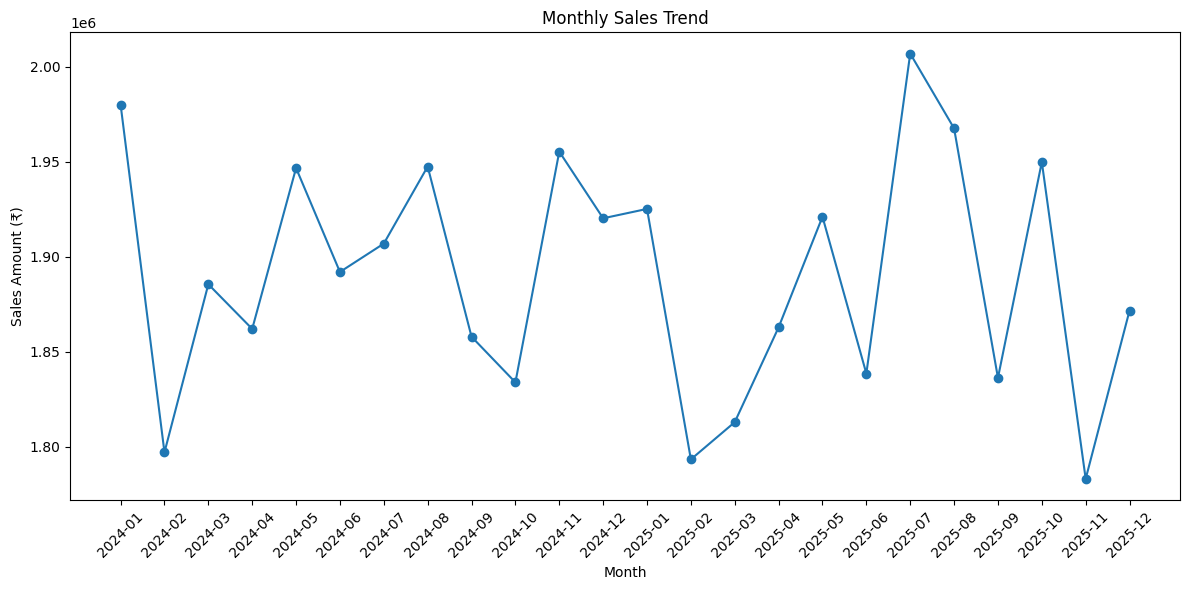

In [34]:
monthly_sales = (
    df.groupby(["year", "month"])["sales_amount"]
    .sum()
    .reset_index()
)

monthly_sales["period"] = (
    monthly_sales["year"].astype(str)
    + "-"
    + monthly_sales["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["period"],
    monthly_sales["sales_amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../Visualizations/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

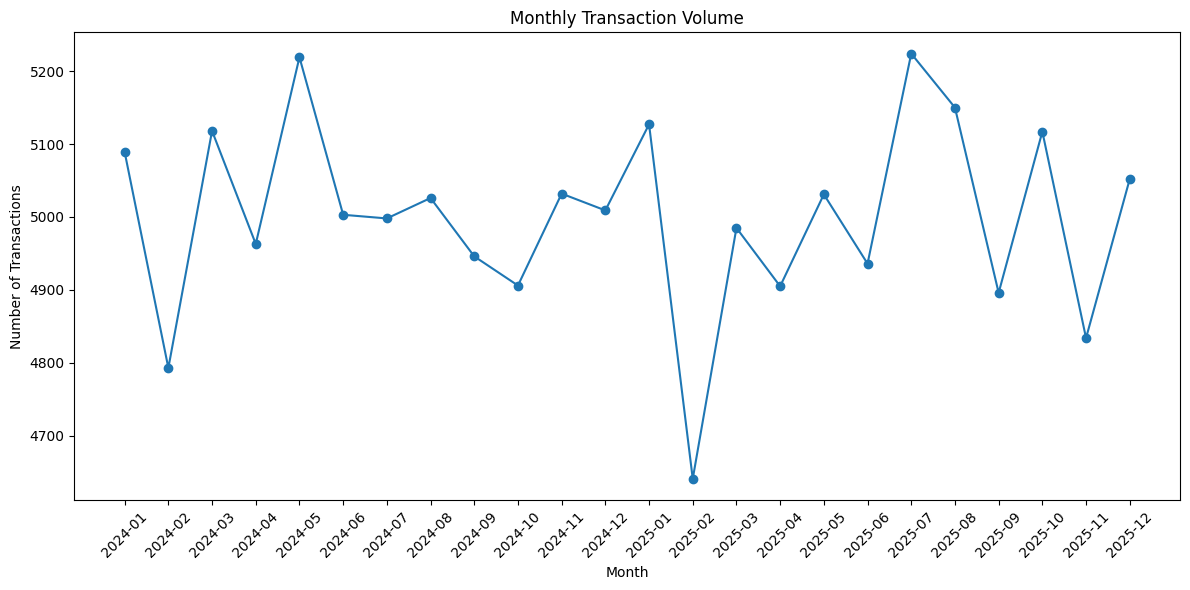

In [35]:
monthly_transactions = (
    df.groupby(["year", "month"])
    .size()
    .reset_index(name="transaction_count")
)

monthly_transactions["period"] = (
    monthly_transactions["year"].astype(str)
    + "-"
    + monthly_transactions["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_transactions["period"],
    monthly_transactions["transaction_count"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_transactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

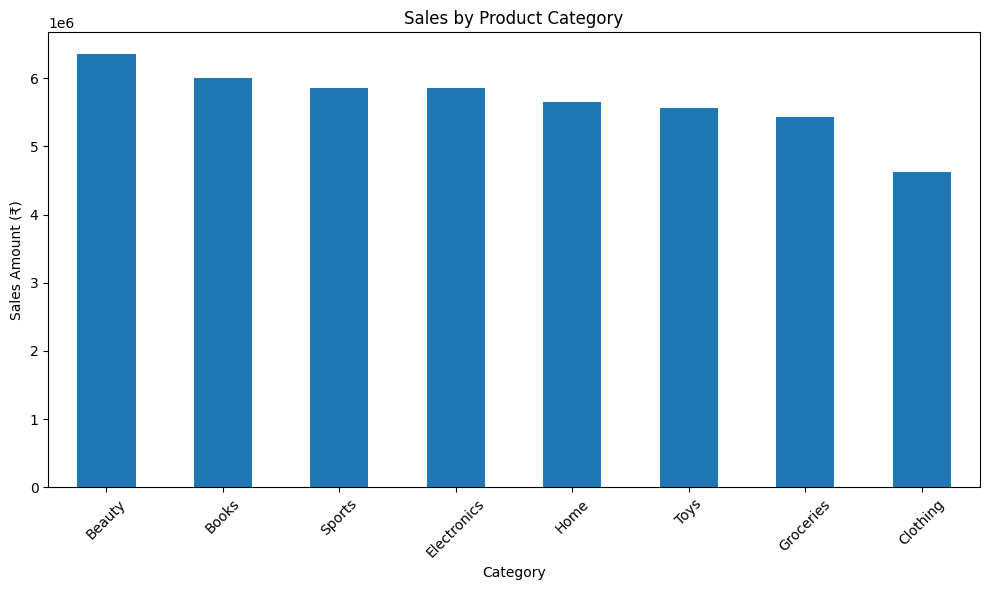

In [37]:
category_sales = (
    df.groupby("category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

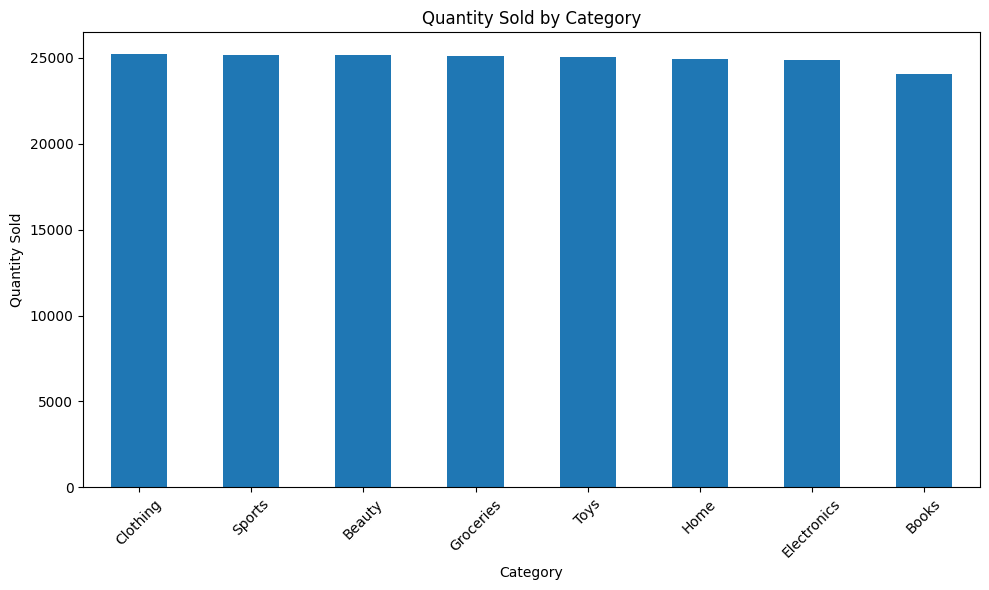

In [38]:
category_quantity = (
    df.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/quantity_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
brand_sales = (
    df.groupby("brand")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Brand:")
display(brand_sales)

Sales by Brand:


brand
Brand 2    15948868.44
Brand 3    15785168.93
Brand 1    13623017.08
Name: sales_amount, dtype: float64

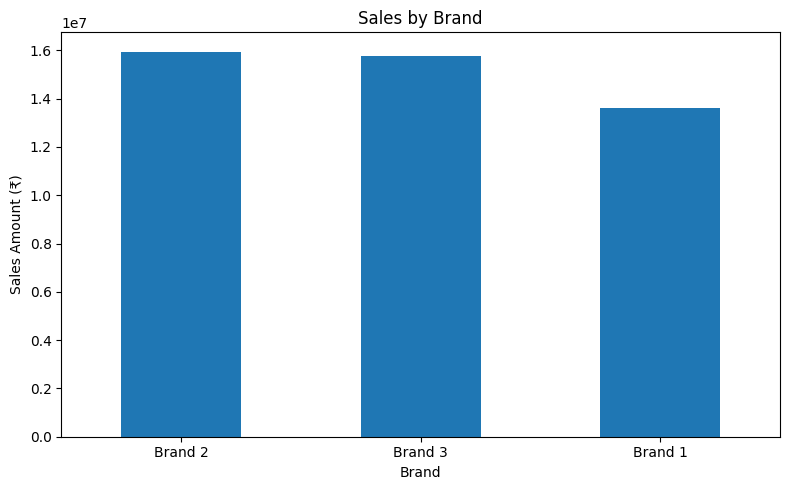

In [40]:
plt.figure(figsize=(8, 5))

brand_sales.plot(kind="bar")

plt.title("Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
segment_sales = (
    df.groupby("customer_segment")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Customer Segment:")
display(segment_sales)

Sales by Customer Segment:


customer_segment
Loyal        11393721.23
New          11331906.60
VIP          11320171.31
Returning    11311255.31
Name: sales_amount, dtype: float64

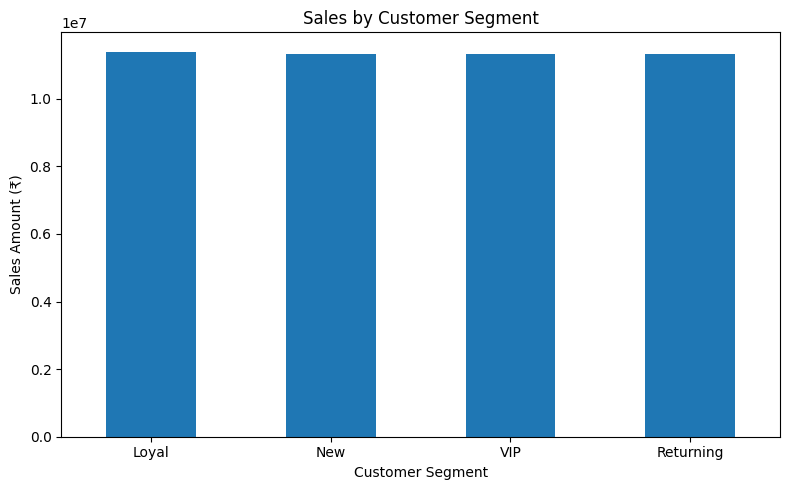

In [42]:
plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
region_sales = (
    df.groupby("region")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Region:")
display(region_sales)

Sales by Region:


region
Central    9237924.11
West       9106911.70
North      9049438.11
South      8991262.89
East       8971517.64
Name: sales_amount, dtype: float64

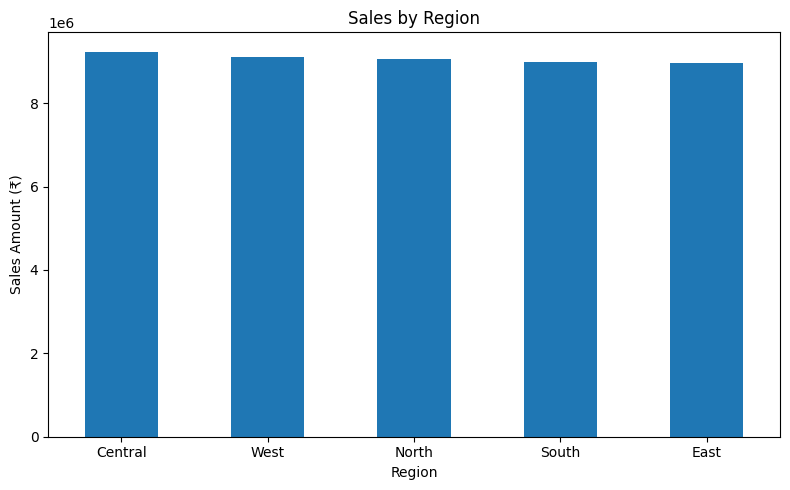

In [44]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
channel_sales = (
    df.groupby("sales_channel")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Channel:")
display(channel_sales)

Sales by Channel:


sales_channel
In-Store      15273226.27
Mobile App    15065983.38
Online        15017844.80
Name: sales_amount, dtype: float64

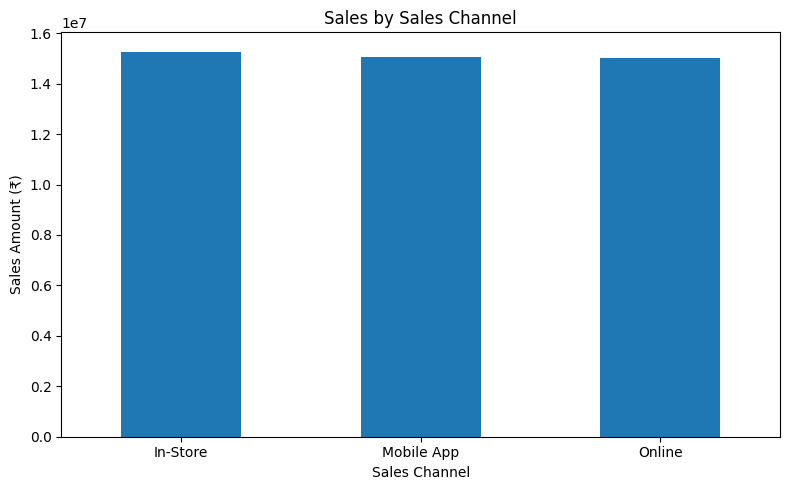

In [46]:
plt.figure(figsize=(8, 5))

channel_sales.plot(kind="bar")

plt.title("Sales by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
payment_sales = (
    df.groupby("payment_method")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Payment Method:")
display(payment_sales)

Sales by Payment Method:


payment_method
Cash           9134699.83
Credit Card    9127113.77
PayPal         9033551.89
Gift Card      9032802.90
Debit Card     9028886.06
Name: sales_amount, dtype: float64

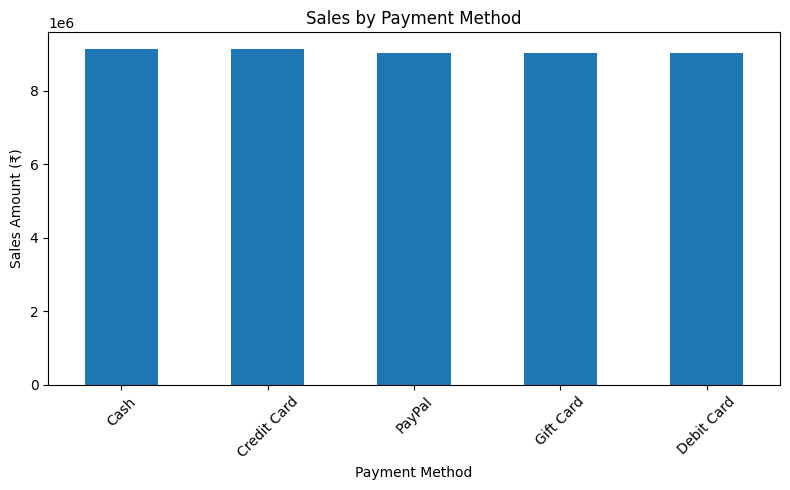

In [48]:
plt.figure(figsize=(8, 5))

payment_sales.plot(kind="bar")

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
age_sales = (
    df.groupby("customer_age_group")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Age Group:")
display(age_sales)

Sales by Age Group:


customer_age_group
35-44    9170231.38
45-54    9091969.39
55+      9085526.85
25-34    9039895.91
18-24    8969430.92
Name: sales_amount, dtype: float64

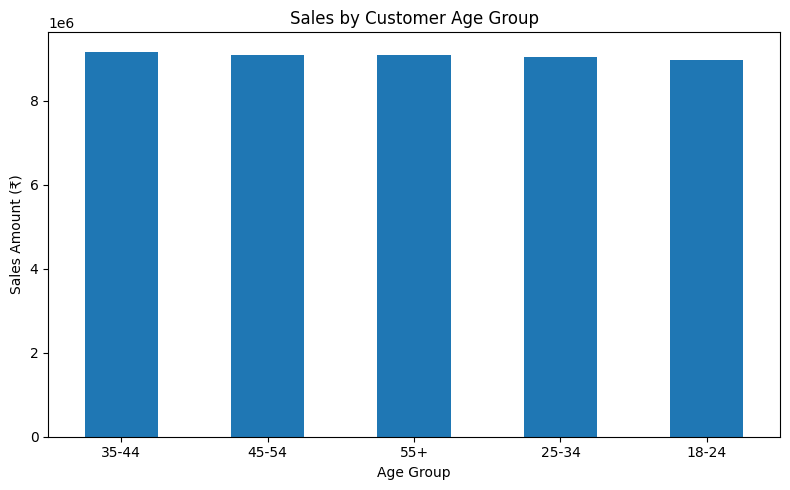

In [50]:
plt.figure(figsize=(8, 5))

age_sales.plot(kind="bar")

plt.title("Sales by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
gender_sales = (
    df.groupby("customer_gender")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by Gender:")
display(gender_sales)

Sales by Gender:


customer_gender
Female    15182360.93
Male      15125990.02
Other     15048703.50
Name: sales_amount, dtype: float64

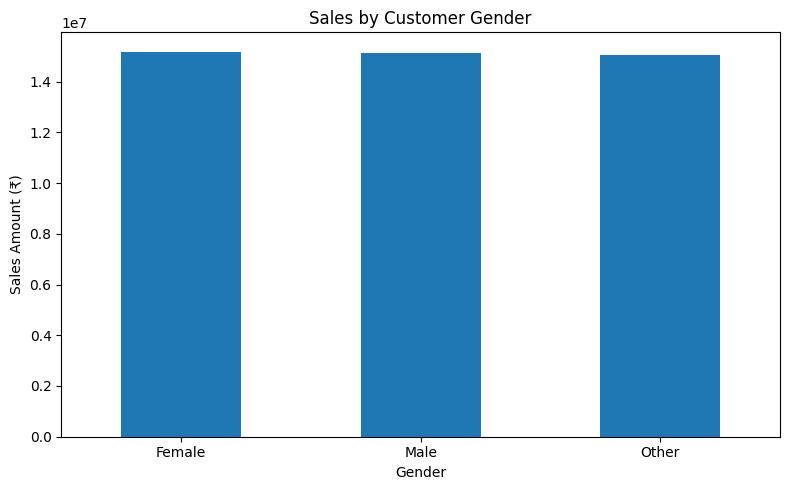

In [52]:
plt.figure(figsize=(8, 5))

gender_sales.plot(kind="bar")

plt.title("Sales by Customer Gender")
plt.xlabel("Gender")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/sales_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
discount_sales = (
    df.groupby("discount_pct")["sales_amount"]
    .mean()
    .reset_index()
)

display(discount_sales)

,discount_pct,sales_amount
0,0,399.465509
1,5,381.917852
2,10,360.452565
3,15,339.633701
4,20,323.275968
5,25,299.897565
6,30,274.179770


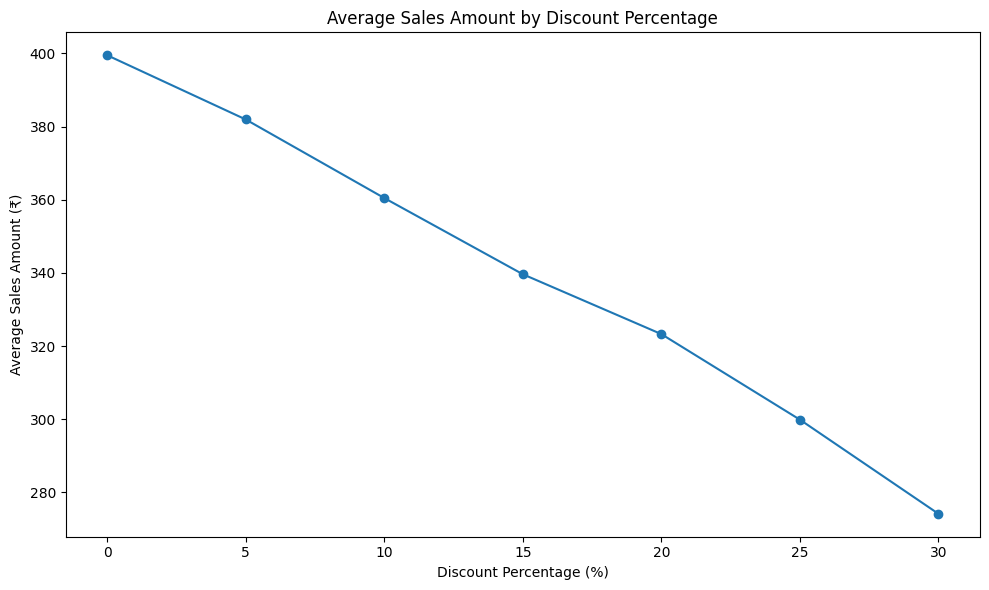

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_sales["discount_pct"],
    discount_sales["sales_amount"],
    marker="o"
)

plt.title("Average Sales Amount by Discount Percentage")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Average Sales Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../visualizations/discount_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

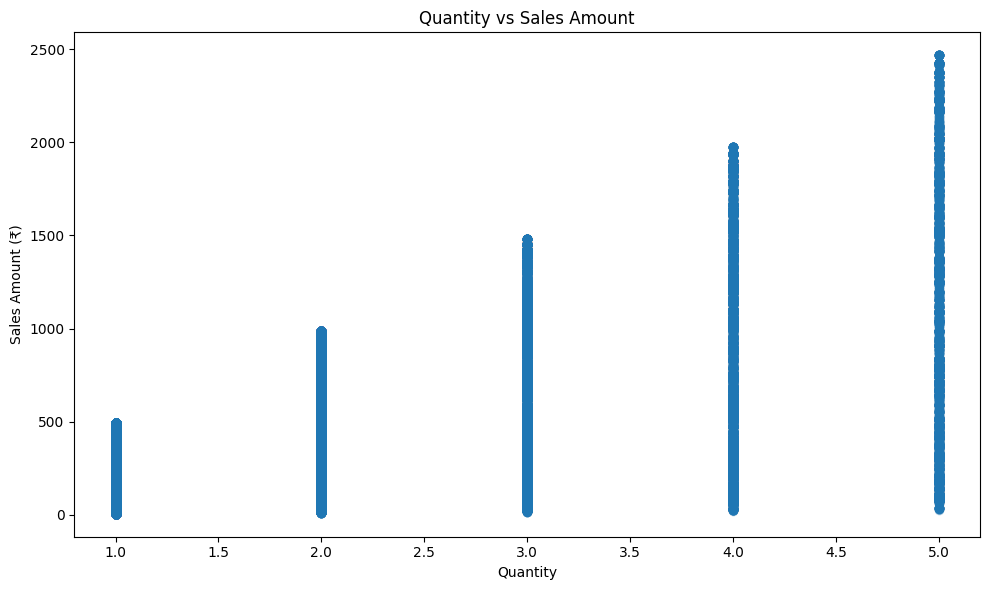

In [55]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["quantity"],
    df["sales_amount"],
    alpha=0.3
)

plt.title("Quantity vs Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../visualizations/quantity_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
top_products = (
    df.groupby("product_name")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Sales:")
display(top_products)

Top 10 Products by Sales:


product_name
Bread              2073770.79
Lipstick           2063017.35
Textbook           1737817.74
Smartphone         1631875.41
Water Bottle       1605400.95
Storage Box        1509331.33
Notebook           1478248.61
Toy Car            1423744.56
Building Blocks    1394417.17
Moisturizer        1348009.02
Name: sales_amount, dtype: float64

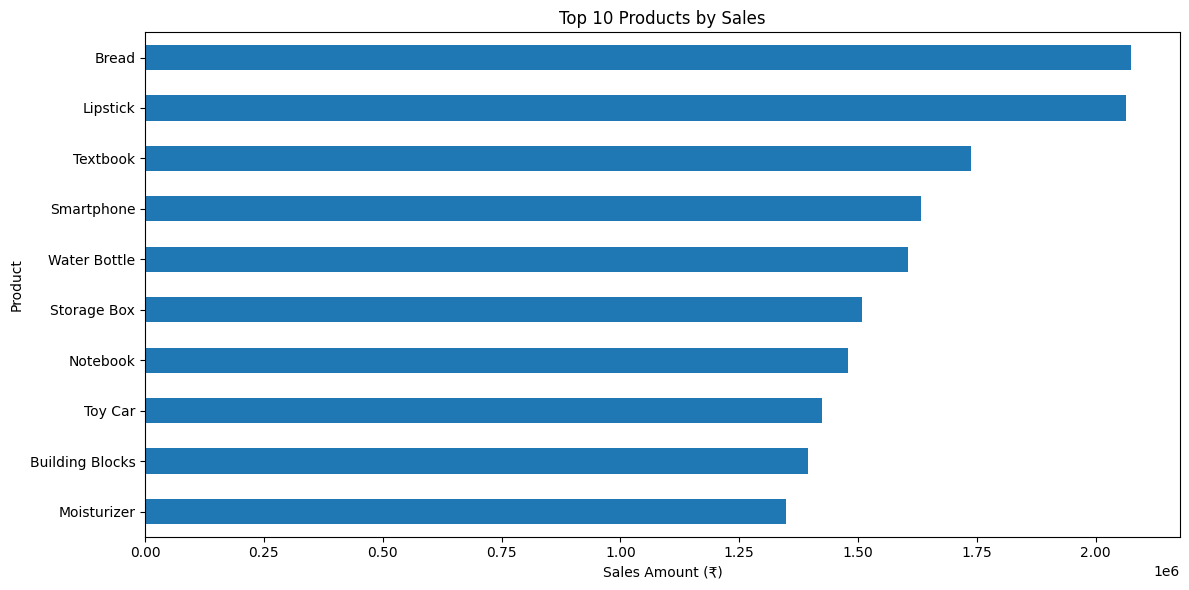

In [57]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_products_by_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
top_quantity_products = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Quantity Sold:")
display(top_quantity_products)

Top 10 Products by Quantity Sold:


product_name
Dumbbells          5212
Lamp               5156
Puzzle             5140
Jeans              5123
Jacket             5116
Cereal             5113
T-Shirt            5099
Shampoo            5089
Building Blocks    5087
Milk               5080
Name: quantity, dtype: int64

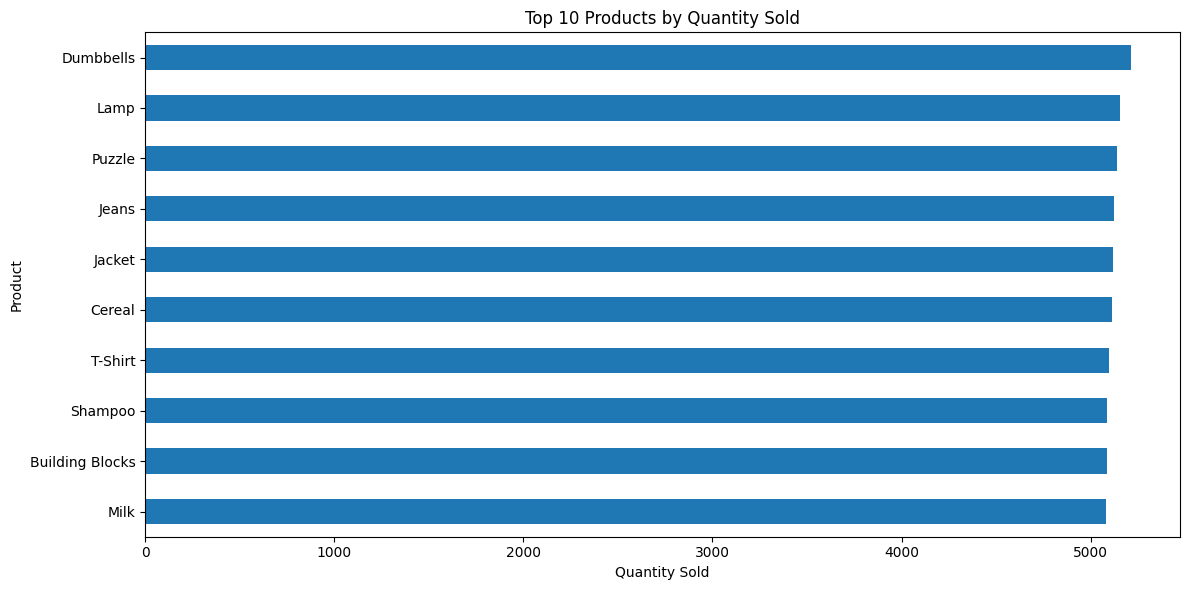

In [59]:
plt.figure(figsize=(12, 6))

top_quantity_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_products_by_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
segment_count = df["customer_segment"].value_counts()

print("Transactions by Customer Segment:")
display(segment_count)

Transactions by Customer Segment:


customer_segment
VIP          30115
New          30020
Loyal        30014
Returning    29851
Name: count, dtype: int64

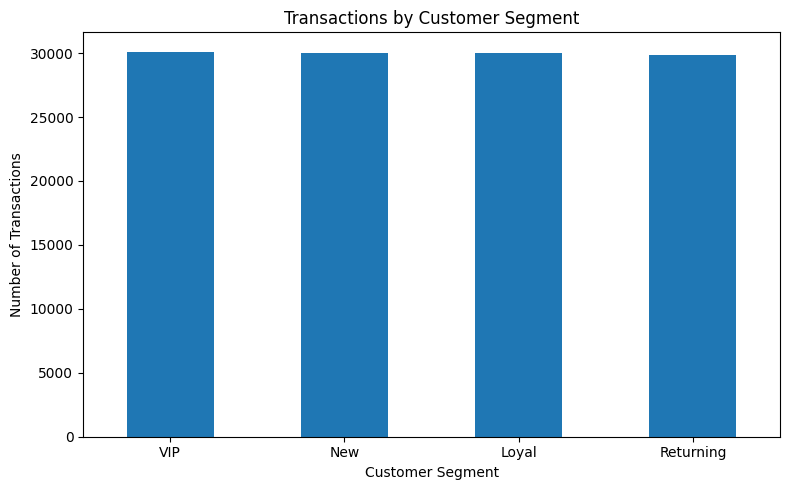

In [61]:
plt.figure(figsize=(8, 5))

segment_count.plot(kind="bar")

plt.title("Transactions by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
avg_segment_sales = (
    df.groupby("customer_segment")["sales_amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Sales Amount by Customer Segment:")
display(avg_segment_sales)

Average Sales Amount by Customer Segment:


customer_segment
Loyal        379.613555
Returning    378.923832
New          377.478568
VIP          375.898101
Name: sales_amount, dtype: float64

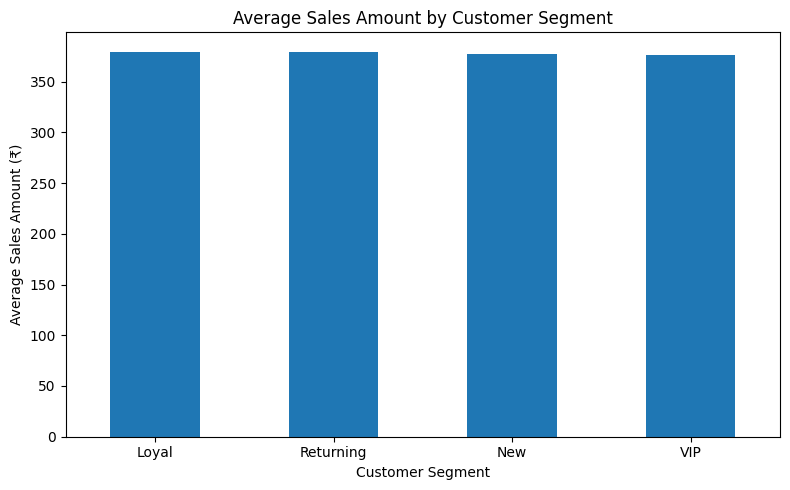

In [63]:
plt.figure(figsize=(8, 5))

avg_segment_sales.plot(kind="bar")

plt.title("Average Sales Amount by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../visualizations/average_sales_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
customer_frequency = (
    df.groupby("customer_id")
    .size()
    .sort_values(ascending=False)
)

print("Top 10 Customers by Number of Transactions:")
display(customer_frequency.head(10))

Top 10 Customers by Number of Transactions:


customer_id
C012115    15
C015257    15
C008880    15
C014343    15
C023479    15
C017090    14
C007590    14
C004651    14
C007618    14
C022195    14
dtype: int64

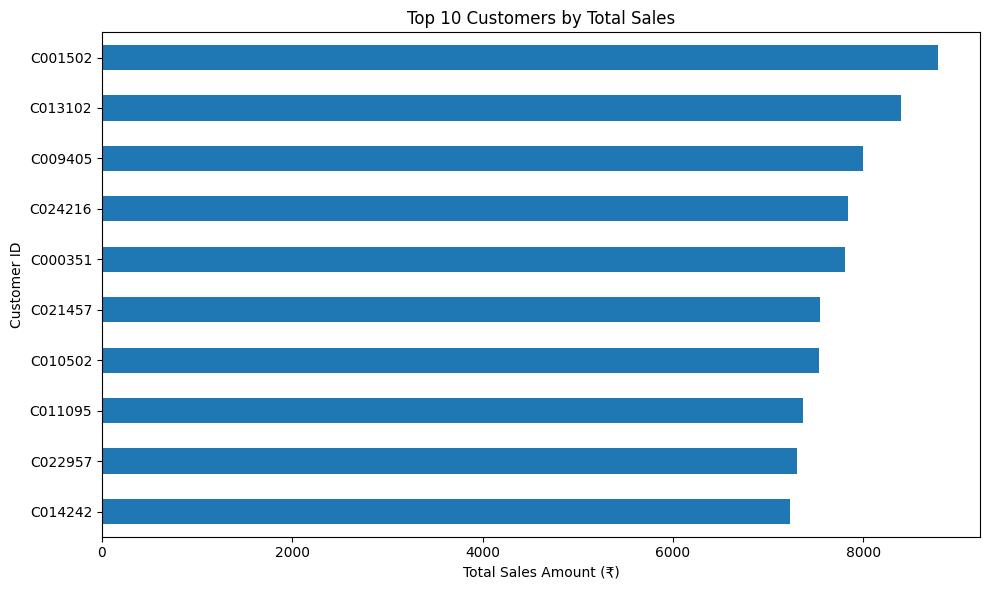

In [66]:
customer_sales = (
    df.groupby("customer_id")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

customer_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales Amount (₹)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_10_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
numeric_cols = [
    "quantity",
    "unit_price",
    "discount_pct",
    "sales_amount",
    "gross_amount",
    "discount_amount"
]

correlation = df[numeric_cols].corr()

display(correlation)

,quantity,unit_price,discount_pct,sales_amount,gross_amount,discount_amount
quantity,1.000000,-0.001101,0.001618,0.644725,0.649979,0.272541
unit_price,-0.001101,1.000000,-0.000484,0.643164,0.648226,0.270522
discount_pct,0.001618,-0.000484,1.000000,-0.091330,0.000284,0.662460
sales_amount,0.644725,0.643164,-0.091330,1.000000,0.992076,0.300716
gross_amount,0.649979,0.648226,0.000284,0.992076,1.000000,0.418159
discount_amount,0.272541,0.270522,0.662460,0.300716,0.418159,1.000000


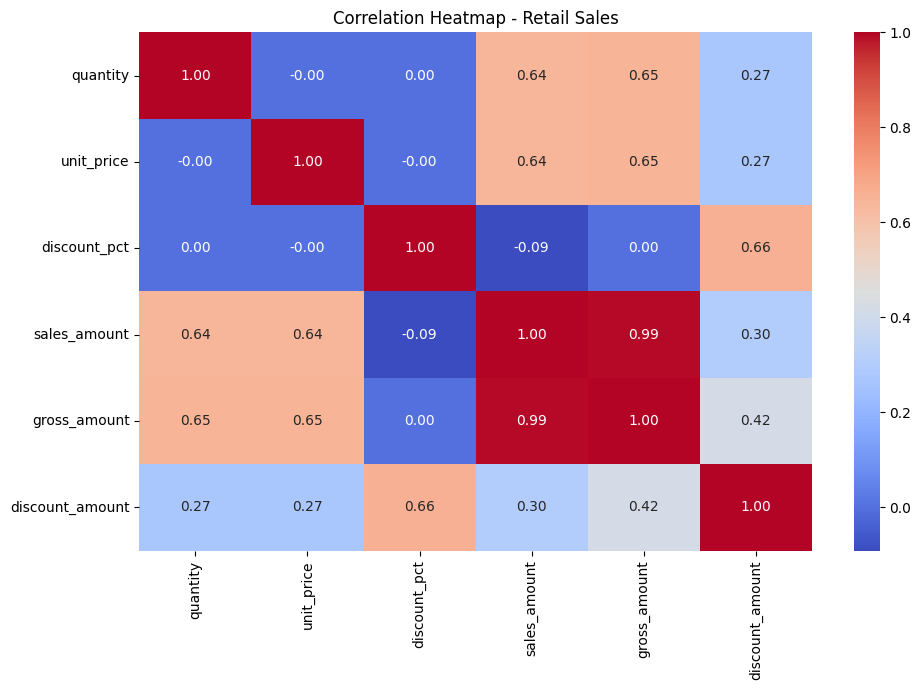

In [68]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Retail Sales")

plt.tight_layout()

plt.savefig(
    "../visualizations/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Sales Prediction

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

target = "sales_amount"

features = [
    "quantity",
    "unit_price",
    "discount_pct",
    "customer_gender",
    "customer_age_group",
    "customer_segment",
    "category",
    "brand",
    "payment_method",
    "sales_channel",
    "region"
]

X = df[features]
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (120000, 11)
Target: (120000,)


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 96000
Testing samples: 24000


In [71]:
categorical_features = [
    "customer_gender",
    "customer_age_group",
    "customer_segment",
    "category",
    "brand",
    "payment_method",
    "sales_channel",
    "region"
]

numeric_features = [
    "quantity",
    "unit_price",
    "discount_pct"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [72]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 97.61786597633764
RMSE: 142.38886938515725
R²: 0.8391698206643738


In [73]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 0.19408096250039064
RMSE: 1.9029098488686276
R²: 0.9999712755388217


In [74]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 0.19408096250039156
RMSE: 1.902909848868628
R²: 0.9999712755388217


In [76]:
gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

gb_model = Pipeline(
    steps=[
        ("preprocessor", gb_preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

display(model_results)

,Model,MAE,RMSE,R2
0,Linear Regression,97.617866,142.388869,0.839170
1,Random Forest,0.194081,1.902910,0.999971
2,Gradient Boosting,6.192488,9.645094,0.999262


In [77]:
model_results.to_csv(
    "../visualizations/model_results.csv",
    index=False
)

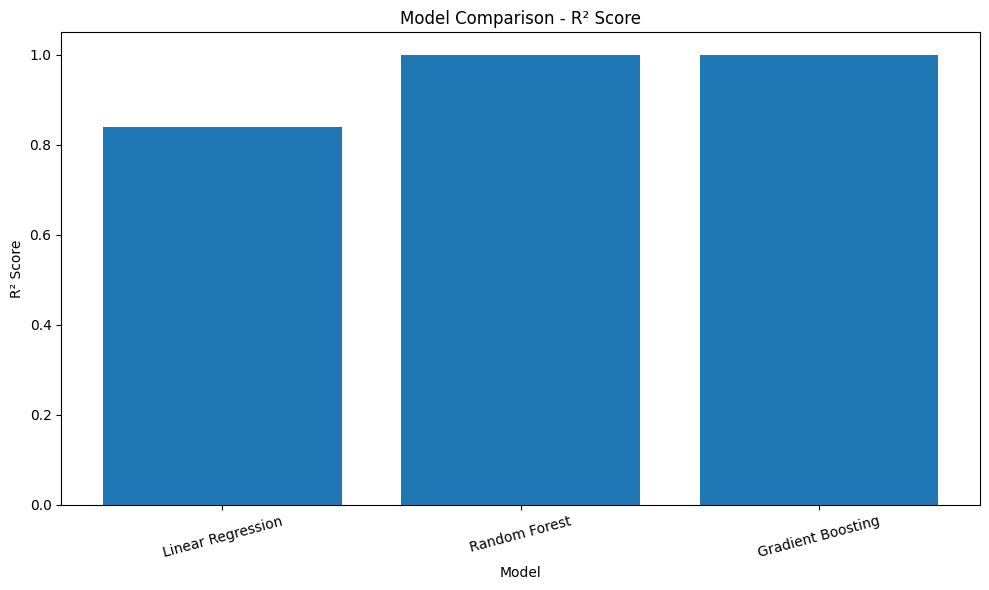

In [80]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["R2"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../visualizations/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

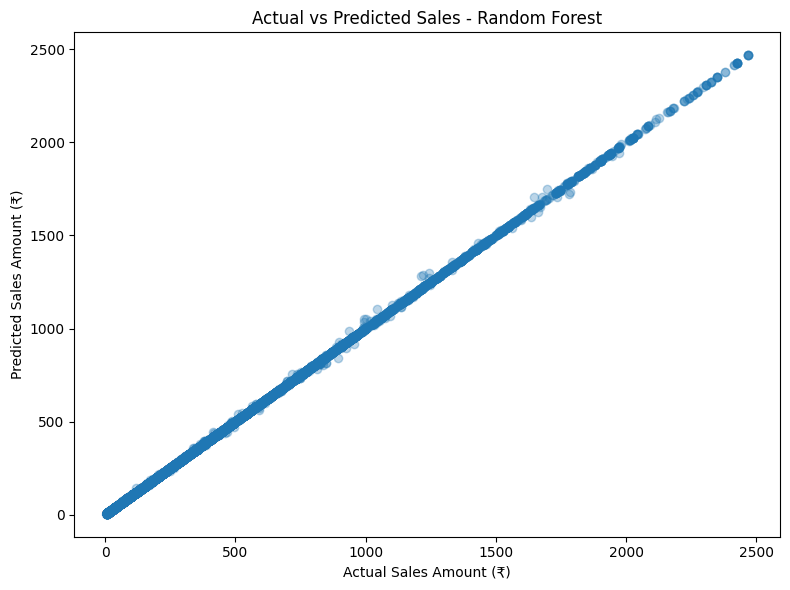

In [81]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.xlabel("Actual Sales Amount (₹)")
plt.ylabel("Predicted Sales Amount (₹)")
plt.title("Actual vs Predicted Sales - Random Forest")

plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

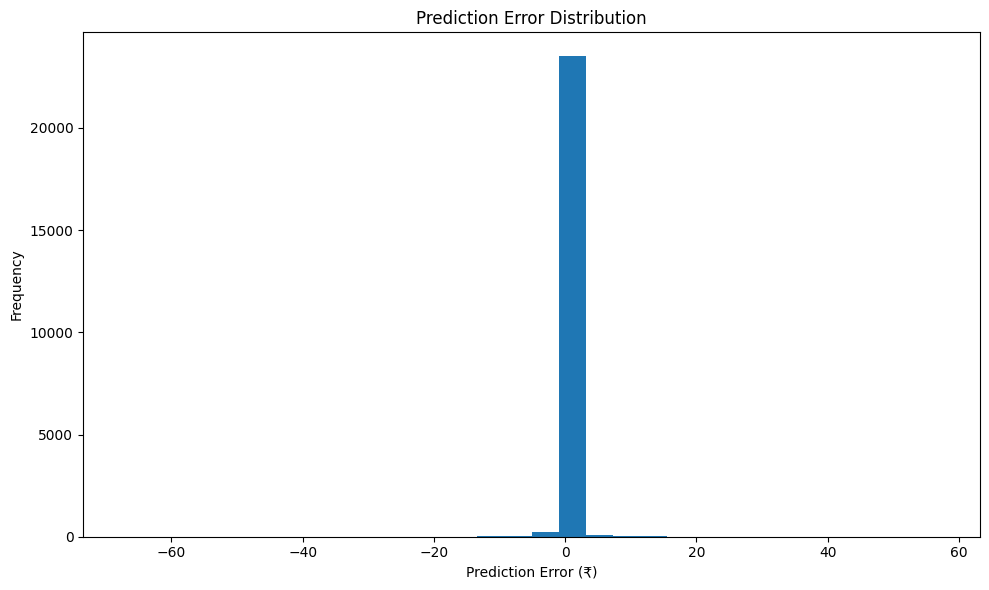

In [82]:
errors = y_test - rf_pred

plt.figure(figsize=(10, 6))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (₹)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../visualizations/prediction_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
import joblib

joblib.dump(
    rf_model,
    "../retail_sales_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [84]:
loaded_model = joblib.load(
    "../retail_sales_prediction_model.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.head(5)
)

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[130.82 218.81 454.25  82.23 214.88]
